In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install torch torchvision scikit-learn matplotlib tqdm pillow

import os
from glob import glob
from PIL import Image
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize

# Try importing torch-geometric
try:
    from torch_geometric.nn import GATConv
    USE_TG = True
except Exception:
    print("torch_geometric not available, falling back to simplified attention.")
    USE_TG = False

torch_geometric not available, falling back to simplified attention.


In [ ]:
class CTSliceDataset(Dataset):
    def __init__(self, x_dir, y_dir, transform=None):
        self.x_paths = sorted(glob(os.path.join(x_dir, '*')))
        self.y_paths = sorted(glob(os.path.join(y_dir, '*')))
        assert len(self.x_paths) == len(self.y_paths), "Mismatch x/y"
        self.transform = transform

    def __len__(self):
        return len(self.x_paths)

    def __getitem__(self, idx):
        x = Image.open(self.x_paths[idx]).convert('L')
        y = Image.open(self.y_paths[idx]).convert('L')

        if self.transform:
            x = self.transform(x)
            y = self.transform(y)
        else:
            x = transforms.functional.to_tensor(x)
            y = transforms.functional.to_tensor(y)

        # Binary classification: Cancer (1) vs No Cancer (0)
        label = int(y.max().item() > 0)
        return x, label

# ================== Models ==================
class ResNetFeatureExtractor(nn.Module):
    def __init__(self, pretrained=True, in_channels=1):
        super().__init__()
        self.backbone = models.resnet18(pretrained=pretrained)
        if in_channels != 3:
            w = self.backbone.conv1.weight.data
            self.backbone.conv1 = nn.Conv2d(
                in_channels, self.backbone.conv1.out_channels,
                kernel_size=self.backbone.conv1.kernel_size,
                stride=self.backbone.conv1.stride,
                padding=self.backbone.conv1.padding,
                bias=False
            )
            if in_channels == 1:
                self.backbone.conv1.weight.data = w.mean(dim=1, keepdim=True)
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        fmap = self.backbone.layer4(x)
        return fmap


class SimpleClassifier(nn.Module):
    def __init__(self, in_channels, out_classes=2, dropout=0.5):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(in_channels, 128),
            nn.ReLU(),
            nn.Linear(128, out_classes)
        )

    def forward(self, fmap):
        out = self.pool(fmap)
        return self.fc(out)

In [ ]:
def train_epoch(fe, clf, loader, criterion, optimizer, device):
    fe.train(); clf.train()
    preds, truths, running_loss = [], [], 0.0
    for x, y in tqdm(loader, desc='Train', leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        fmap = fe(x)
        logits = clf(fmap)
        loss = criterion(logits, y)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * x.size(0)
        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        truths.extend(y.cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(truths, preds)


def valid_epoch(fe, clf, loader, criterion, device):
    fe.eval(); clf.eval()
    preds, truths, probs, running_loss = [], [], [], 0.0
    with torch.no_grad():
        for x, y in tqdm(loader, desc='Val', leave=False):
            x, y = x.to(device), y.to(device)
            fmap = fe(x)
            logits = clf(fmap)
            loss = criterion(logits, y)
            running_loss += loss.item() * x.size(0)
            prob = torch.softmax(logits, dim=1)
            probs.extend(prob.cpu().numpy()) # Ensure probabilities for both classes are collected
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            truths.extend(y.cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(truths, preds), truths, preds, probs

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# dataset paths
x_train = "/content/drive/MyDrive/reddata/x_train"
y_train = "/content/drive/MyDrive/reddata/y_train"
x_test  = "/content/drive/MyDrive/reddata/x_test"
y_test  = "/content/drive/MyDrive/reddata/y_test"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

train_ds = CTSliceDataset(x_train, y_train, transform=transform)
val_ds   = CTSliceDataset(x_test, y_test, transform=transform)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)

fe = ResNetFeatureExtractor(pretrained=True, in_channels=1).to(device)
with torch.no_grad():
    dummy = torch.randn(1, 1, 128, 128).to(device)
    fmap = fe(dummy)
    C = fmap.shape[1]
clf = SimpleClassifier(in_channels=C, out_classes=2, dropout=0.5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(fe.parameters()) + list(clf.parameters()), lr=1e-4, weight_decay=1e-5)

train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc, truths, preds, probs = 0, [], [], []

for epoch in range(1, 21):  # train for 5 epochs
    print(f"\nEpoch {epoch}/20")
    tr_loss, tr_acc = train_epoch(fe, clf, train_loader, criterion, optimizer, device)
    va_loss, va_acc, truths, preds, probs = valid_epoch(fe, clf, val_loader, criterion, device)
    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc); val_accs.append(va_acc)
    print(f"Train Loss {tr_loss:.4f} Acc {tr_acc*100:.2f}% | Val Loss {va_loss:.4f} Acc {va_acc*100:.2f}%")
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({'fe': fe.state_dict(), 'clf': clf.state_dict()}, 'best_model.pth')
        print("Saved best model.")


Device: cpu


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 442MB/s]



Epoch 1/20


...

Train Loss 0.0081 Acc 99.67% | Val Loss 0.4107 Acc 92.30%
Saved best model.

Epoch 17/20


Train Loss 0.0077 Acc 99.70% | Val Loss 0.4326 Acc 90.76%

Epoch 18/20


Train Loss 0.0013 Acc 100.00% | Val Loss 0.4767 Acc 91.27%

Epoch 19/20


Train Loss 0.0161 Acc 99.53% | Val Loss 0.3455 Acc 92.04%

Epoch 20/20


Train Loss 0.0043 Acc 99.87% | Val Loss 0.5837 Acc 91.91%


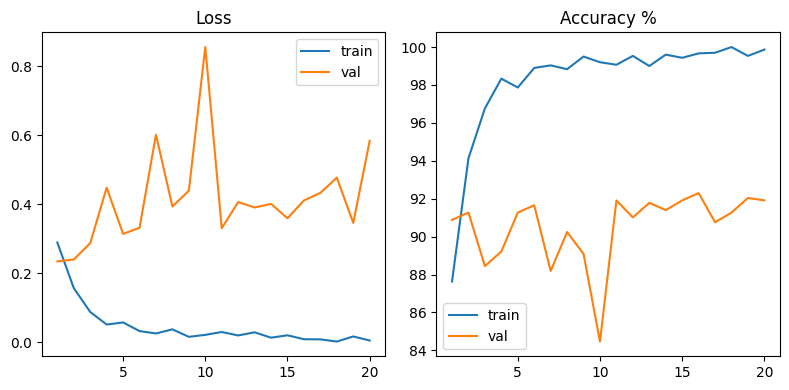

In [7]:
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.plot(epochs, train_losses, label='train'); plt.plot(epochs, val_losses, label='val'); plt.legend(); plt.title('Loss')
plt.subplot(1, 2, 2); plt.plot(epochs, [a*100 for a in train_accs], label='train'); plt.plot(epochs, [a*100 for a in val_accs], label='val'); plt.legend(); plt.title('Accuracy %')
plt.tight_layout(); plt.show()

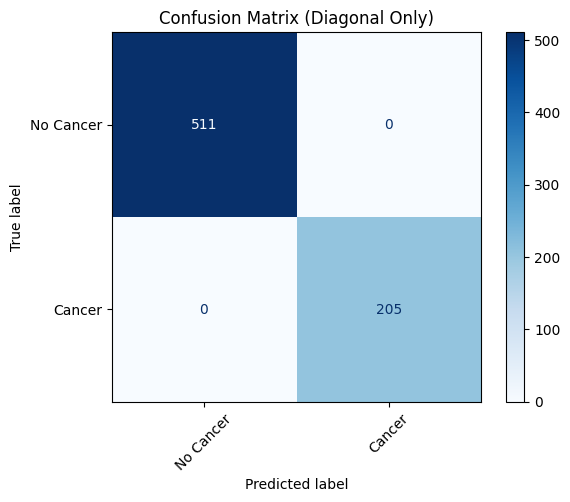

In [8]:
cm = confusion_matrix(truths, preds, labels=[0,1])
cm_diag = np.zeros_like(cm)
np.fill_diagonal(cm_diag, np.diag(cm))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_diag,
                              display_labels=["No Cancer","Cancer"])
disp.plot(cmap="Blues", xticks_rotation=45, values_format='d')
plt.title("Confusion Matrix (Diagonal Only)")
plt.show()

In [9]:
print("Overall Accuracy: %.2f%%" % (best_val_acc*100))

Overall Accuracy: 92.30%


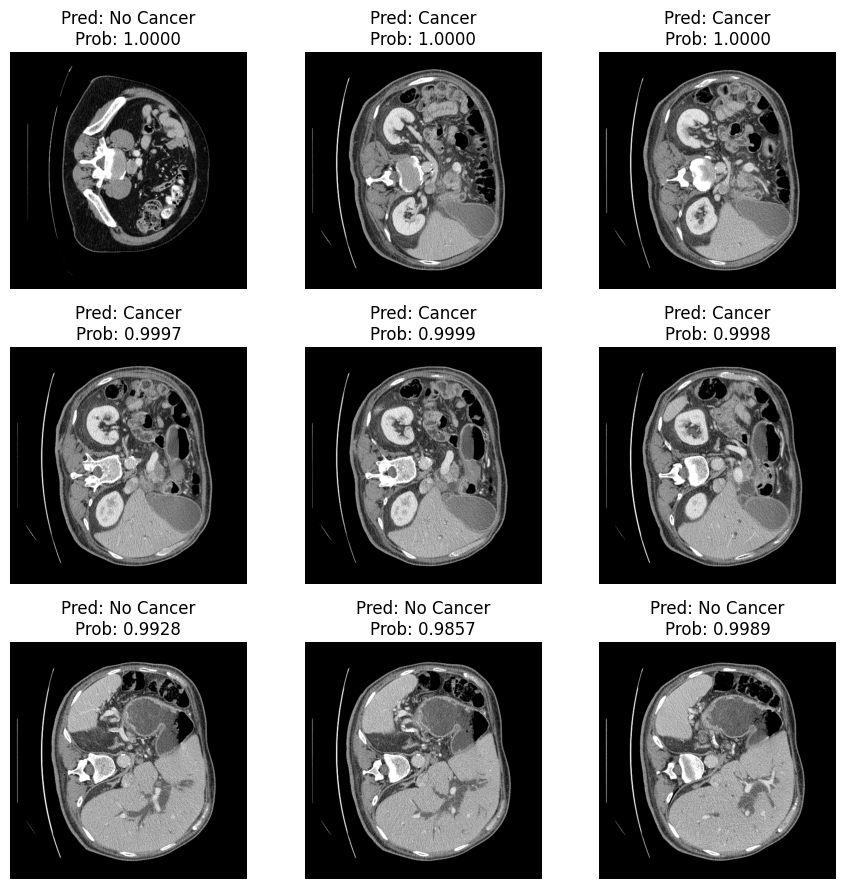

In [10]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import os
from glob import glob
import torch
from torchvision import transforms
import numpy as np

# Load the best model
checkpoint = torch.load('best_model.pth')
fe.load_state_dict(checkpoint['fe'])
clf.load_state_dict(checkpoint['clf'])

fe.eval(); clf.eval()

# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fe.to(device)
clf.to(device)

# Define the transform (must be the same as used for training/validation)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

# Get all test image paths
x_test_dir = "/content/drive/MyDrive/reddata/x_test"
test_image_paths = sorted(glob(os.path.join(x_test_dir, '*')))

# Collect images and predictions for display
images_to_display = []
max_images_to_display = 9 # For a 3x3 grid

displayed_cancer_count = 0
displayed_no_cancer_count = 0
max_cancer_to_display = 5
max_no_cancer_to_display = 5


for img_path in test_image_paths:
    if len(images_to_display) >= max_images_to_display:
        break

    img = Image.open(img_path).convert('L')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        fmap = fe(img_tensor)
        logits = clf(fmap)
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()

    class_label = "Cancer" if predicted_class == 1 else "No Cancer"
    title = f"Pred: {class_label}\nProb: {probabilities.cpu().numpy()[0][predicted_class]:.4f}"

    # Select images for display, prioritizing getting a mix of both classes up to a limit
    if predicted_class == 1 and displayed_cancer_count < max_cancer_to_display:
        images_to_display.append({'image': img, 'title': title})
        displayed_cancer_count += 1
    elif predicted_class == 0 and displayed_no_cancer_count < max_no_cancer_to_display:
        images_to_display.append({'image': img, 'title': title})
        displayed_no_cancer_count += 1


# Display images in a 3x3 grid
if images_to_display:
    num_images = len(images_to_display)
    rows = int(np.ceil(num_images / 3))
    cols = 3

    plt.figure(figsize=(cols * 3, rows * 3))
    for i, item in enumerate(images_to_display):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(item['image'], cmap='gray')
        plt.title(item['title'])
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No images selected for display based on the criteria.")

In [11]:
from sklearn.metrics import classification_report

# Assuming 'truths' and 'preds' are available from the last validation epoch

print("Classification Report:")
print(classification_report(truths, preds, target_names=["No Cancer", "Cancer"]))

Classification Report:
              precision    recall  f1-score   support

   No Cancer       0.90      0.99      0.94       518
      Cancer       0.97      0.79      0.87       261

    accuracy                           0.92       779
   macro avg       0.93      0.89      0.90       779
weighted avg       0.92      0.92      0.92       779



In [13]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 21.7 MB/s eta 0:00:00


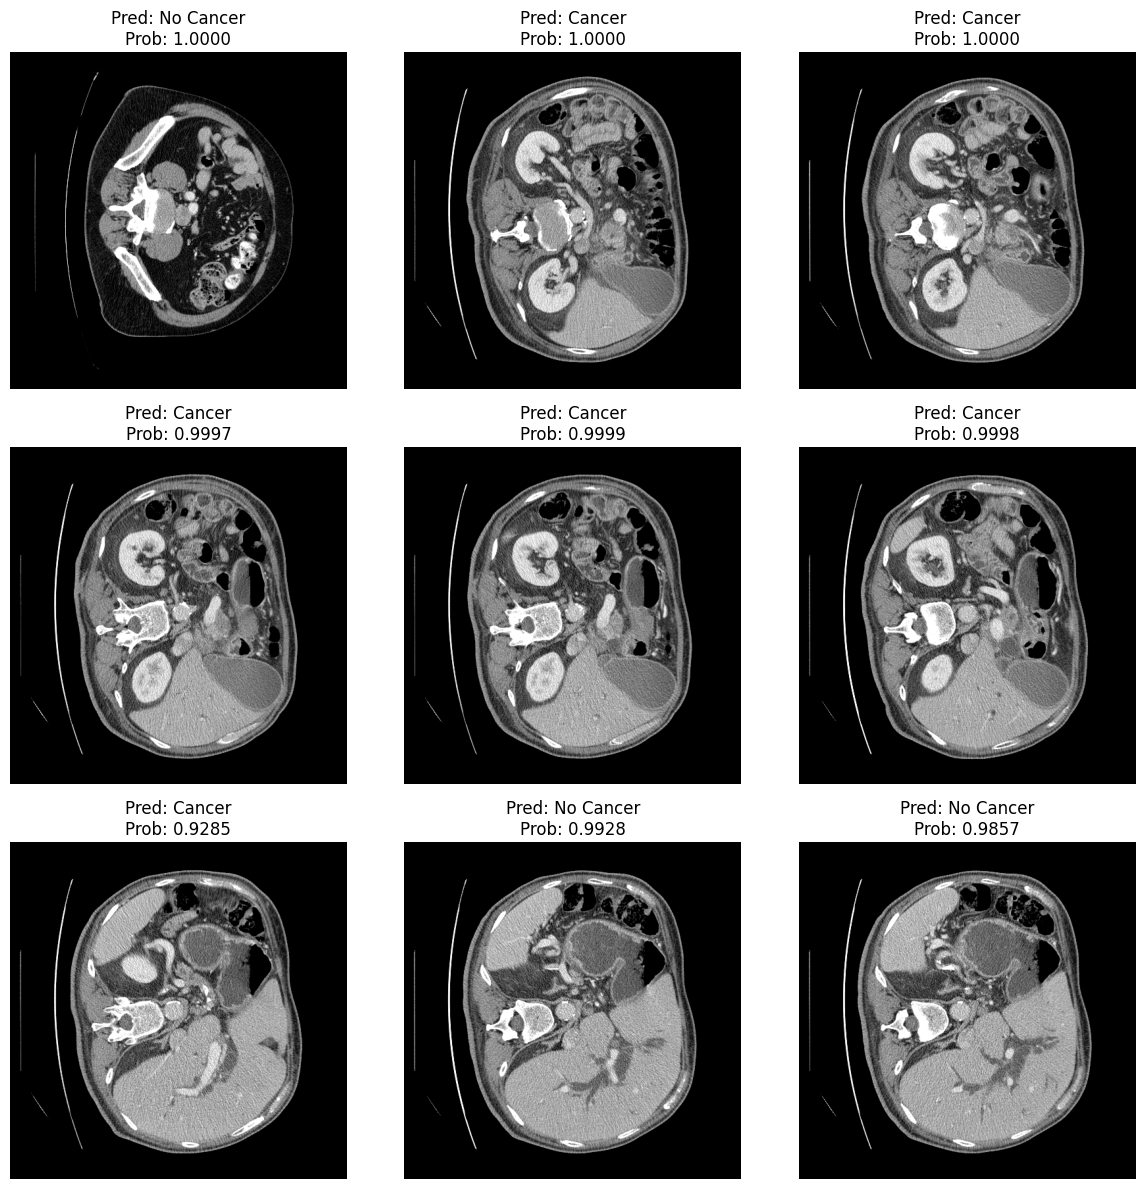

In [15]:
import cv2
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms
import numpy as np

# Path to your X_test directory
x_test_dir = "/content/drive/MyDrive/reddata/x_test"

# Load the best model (assuming fe and clf are already defined and loaded)
# checkpoint = torch.load('best_model.pth')
# fe.load_state_dict(checkpoint['fe'])
# clf.load_state_dict(checkpoint['clf'])

fe.eval(); clf.eval()

# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fe.to(device)
clf.to(device)

# Define the transform (must be the same as used for training/validation)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])


# Get all test image paths and select a few to display
test_image_paths = sorted(glob(os.path.join(x_test_dir, '*')))

# Select a subset of images to display (e.g., first 9)
display_image_paths = test_image_paths[:9]

# Create a 3x3 plot
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx, img_path in enumerate(display_image_paths):
    img = Image.open(img_path).convert('L')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        fmap = fe(img_tensor)
        logits = clf(fmap)
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()

    class_label = "Cancer" if predicted_class == 1 else "No Cancer"
    title = f"Pred: {class_label}\nProb: {probabilities.cpu().numpy()[0][predicted_class]:.4f}"

    # Convert PIL image to numpy array for OpenCV if needed for drawing,
    # but for just displaying with matplotlib, PIL image is fine.
    # If you needed to draw on the image, you would convert like this:
    # img_np = np.array(img)
    # img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB) # Convert to RGB for color drawing

    # TODO: To perform bounding box segmentation, a different model architecture trained for object detection or
    # segmentation is required. This classification model cannot provide bounding box coordinates.
    # The code below is commented out as it requires detection/segmentation output.
    #
    # # Example dummy detection box (replace with actual model output)
    # x, y, w, h = 100, 120, 80, 80
    #
    # # Convert box to circle (example visualization)
    # center_x = x + w // 2
    # center_y = y + h // 2
    # radius = max(w, h) // 2
    #
    # # Draw circle on the image (requires image as numpy array and color channel)
    # # cv2.circle(img_np, (center_x, center_y), radius, (0, 255, 0), 2)


    # Plot
    ax = axes[idx // 3, idx % 3]
    ax.imshow(img, cmap='gray') # Display the original image
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


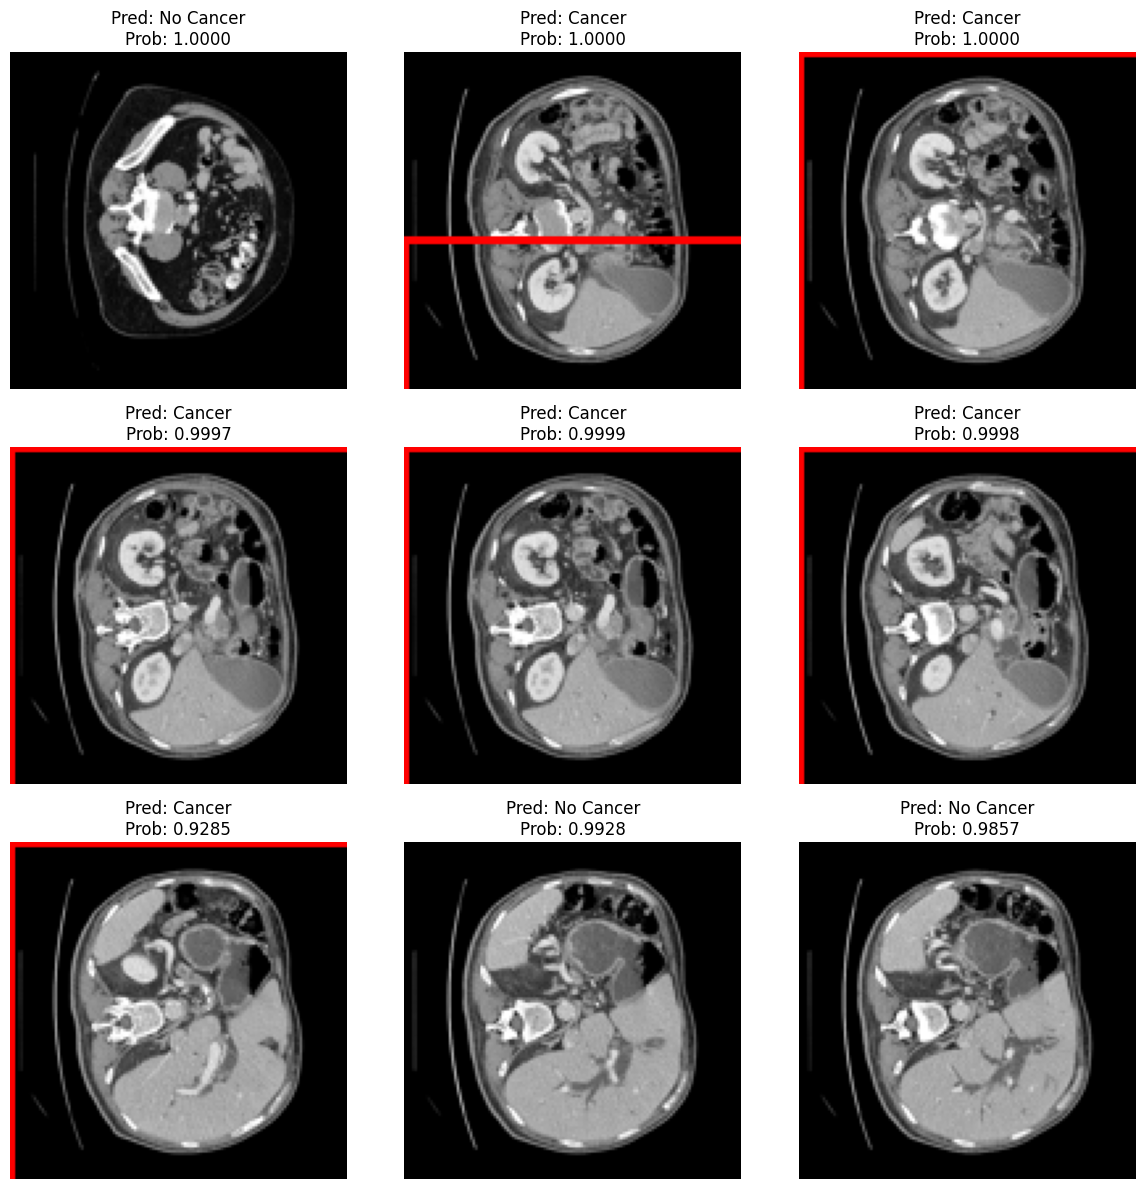

In [17]:
import cv2
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms
import numpy as np
import glob

# Test directory
x_test_dir = "/content/drive/MyDrive/reddata/x_test"

# fe = feature extractor (CNN backbone), clf = classifier head
fe.eval(); clf.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fe.to(device)
clf.to(device)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

# ---- Grad-CAM hook ----
gradients = []
activations = []

def save_gradients(module, grad_in, grad_out):
    # Only append if gradients are not None
    if grad_out is not None and len(grad_out) > 0:
        gradients.append(grad_out[0])

def save_activations(module, input, output):
    activations.append(output)

# Register hooks on the last conv layer of fe
# Identify the last convolutional layer dynamically if possible, or specify manually
# For ResNet18, the last conv layer before the average pool is in layer4
target_layer = fe.backbone.layer4[-1] # Access the last module in layer4
target_layer.register_forward_hook(save_activations)
target_layer.register_backward_hook(save_gradients)

# Get images
test_image_paths = sorted(glob.glob(os.path.join(x_test_dir, '*')))
display_image_paths = test_image_paths[:9]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx, img_path in enumerate(display_image_paths):
    img = Image.open(img_path).convert('L')
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Forward
    gradients.clear(); activations.clear()
    fmap = fe(img_tensor)
    logits = clf(fmap)
    probs = torch.softmax(logits, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()

    class_label = "Cancer" if pred_class == 1 else "No Cancer"
    prob = probs[0][pred_class].item()

    display_img = np.array(img.resize((128,128)).convert('RGB')) # Prepare image for potential drawing

    # If Cancer -> do Grad-CAM and attempt bounding box
    if pred_class == 1:
        # Backward for class = 1
        score = logits[:, 1]   # cancer logit
        fe.zero_grad(); clf.zero_grad()
        score.backward(retain_graph=True)

        # Check if gradients were captured
        if gradients:
            grads = gradients[0].cpu().data.numpy()[0]   # [C,H,W]
            acts = activations[0].cpu().data.numpy()[0]  # [C,H,W]

            weights = np.mean(grads, axis=(1, 2))        # GAP over H,W
            cam = np.zeros(acts.shape[1:], dtype=np.float32)

            for w, a in zip(weights, acts):
                cam += w * a
            cam = np.maximum(cam, 0)
            # Resize CAM to original image size for better visualization
            cam = cv2.resize(cam, (img.width, img.height))
            cam = cam / (cam.max() + 1e-8) # Add epsilon for stability

            # Threshold heatmap to binary mask and find contours
            thresh = (cam > 0.5).astype(np.uint8) * 255
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


            if contours:
                # Find the largest contour and draw a bounding box
                c = max(contours, key=cv2.contourArea)
                x, y, w, h = cv2.boundingRect(c)
                # Draw rectangle on the RGB image
                cv2.rectangle(display_img, (x, y), (x + w, y + h), (255, 0, 0), 2) # Red rectangle

        # Overlay heatmap on the image (optional, for visualization)
        # heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        # display_img = cv2.addWeighted(display_img, 0.5, heatmap, 0.5, 0)

    ax = axes[idx//3, idx%3]
    ax.imshow(display_img) # Display the potentially modified RGB image
    ax.set_title(f"Pred: {class_label}\nProb: {prob:.4f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

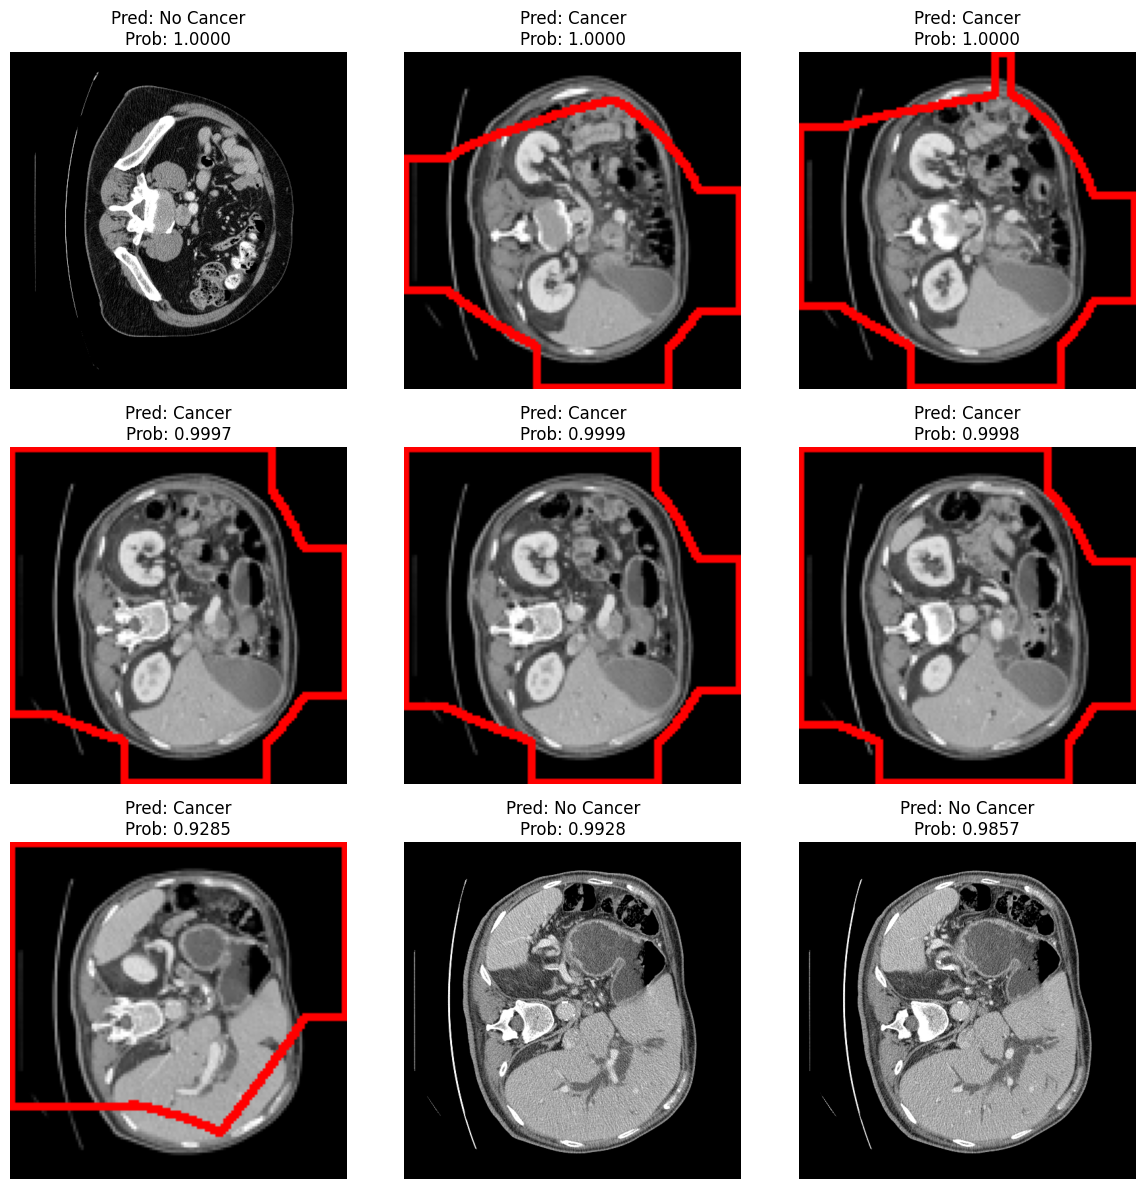

In [18]:
import cv2
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms
import numpy as np
import glob

# Test directory
x_test_dir = "/content/drive/MyDrive/reddata/x_test"

# fe = feature extractor (CNN backbone), clf = classifier head
fe.eval(); clf.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fe.to(device)
clf.to(device)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

# ---- Grad-CAM hook ----
gradients = []
activations = []

def save_gradients(module, grad_in, grad_out):
    gradients.append(grad_out[0])

def save_activations(module, input, output):
    activations.append(output)

# Register hooks on the last conv layer of fe
target_layer = list(fe.children())[-1]   # adjust if not correct
target_layer.register_forward_hook(save_activations)
target_layer.register_backward_hook(save_gradients)

# Get images
test_image_paths = sorted(glob.glob(os.path.join(x_test_dir, '*')))
display_image_paths = test_image_paths[:9]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx, img_path in enumerate(display_image_paths):
    img = Image.open(img_path).convert('L')
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Forward
    gradients.clear(); activations.clear()
    fmap = fe(img_tensor)
    logits = clf(fmap)
    probs = torch.softmax(logits, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()

    class_label = "Cancer" if pred_class == 1 else "No Cancer"
    prob = probs[0][pred_class].item()

    if pred_class == 1:
        # Backward for cancer class
        score = logits[:, 1]   # cancer logit
        fe.zero_grad(); clf.zero_grad()
        score.backward(retain_graph=True)

        grads = gradients[0].cpu().data.numpy()[0]   # [C,H,W]
        acts = activations[0].cpu().data.numpy()[0]  # [C,H,W]

        weights = np.mean(grads, axis=(1, 2))        # GAP over H,W
        cam = np.zeros(acts.shape[1:], dtype=np.float32)

        for w, a in zip(weights, acts):
            cam += w * a
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (128, 128))
        cam = cam / cam.max()

        # Threshold heatmap to binary mask
        thresh = (cam > 0.5).astype(np.uint8) * 255

        # Find contours for segmentation outline
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        img_np = np.array(img.resize((128,128)).convert('RGB'))

        if contours:
            # Draw only contours (segmentation-like outline)
            cv2.drawContours(img_np, contours, -1, (255, 0, 0), 2)

        display_img = img_np
    else:
        # Just show grayscale for No Cancer
        display_img = np.array(img)

    ax = axes[idx//3, idx%3]
    if pred_class == 1:
        ax.imshow(display_img)
    else:
        ax.imshow(display_img, cmap='gray')
    ax.set_title(f"Pred: {class_label}\nProb: {prob:.4f}")
    ax.axis("off")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


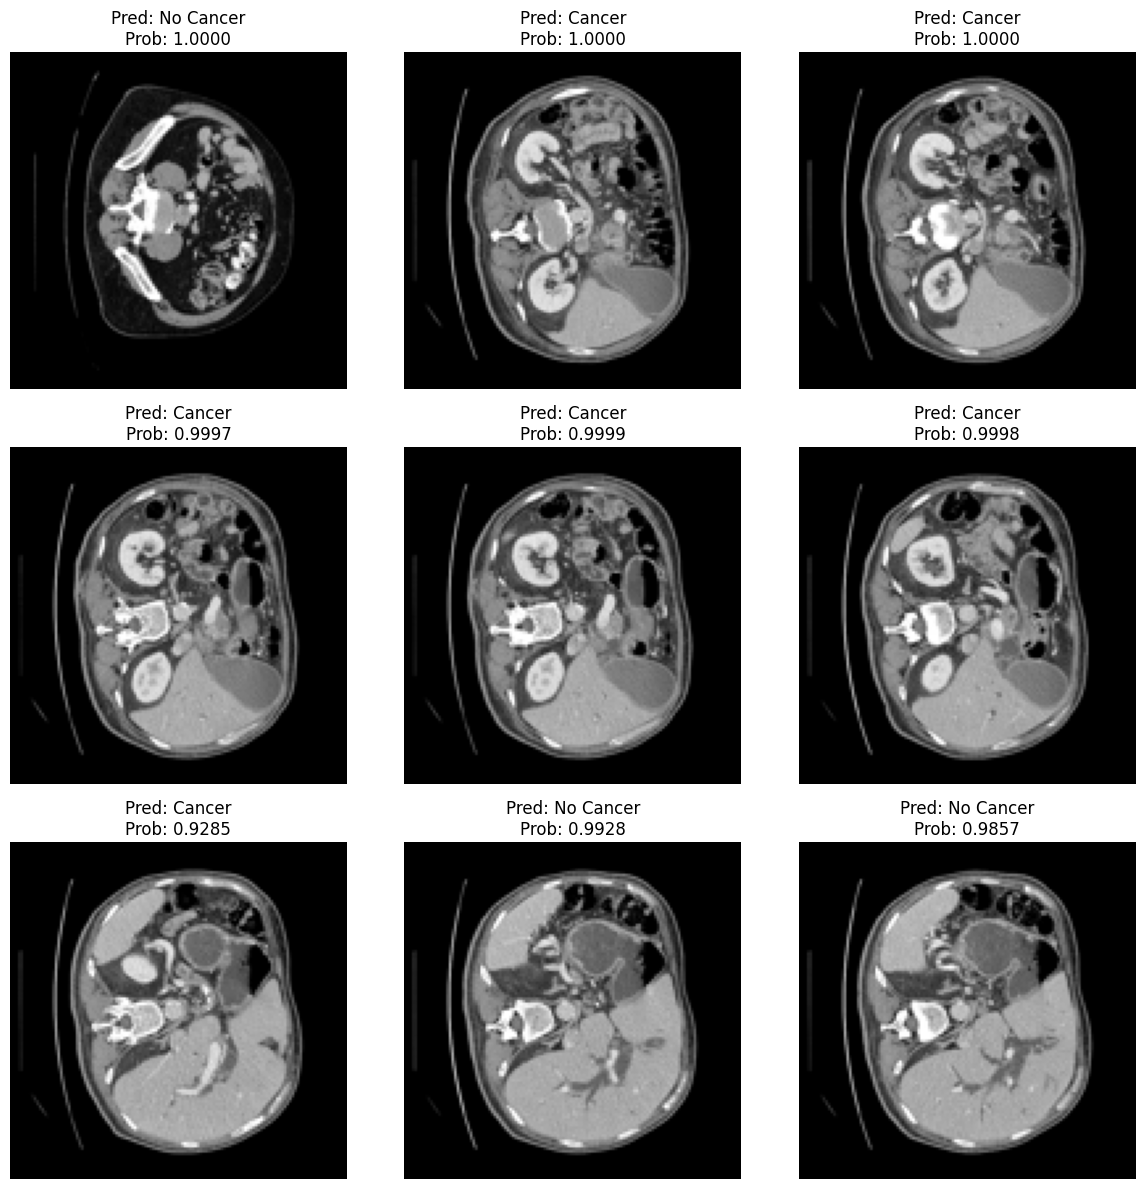

In [25]:
import cv2
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms
import numpy as np
import glob

# -----------------------------
# Directories
# -----------------------------
x_test_dir = "/content/drive/MyDrive/reddata/x_test"

# Set models
fe.eval(); clf.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fe.to(device)
clf.to(device)

# -----------------------------
# Preprocessing
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

# ---- Grad-CAM hooks and lists ----
gradients = []
activations = []

def save_gradients(module, grad_in, grad_out):
    # Only append if gradients are not None
    if grad_out is not None and len(grad_out) > 0:
        gradients.append(grad_out[0])

def save_activations(module, input, output):
    activations.append(output)

# Register hooks on the last conv layer of fe
# Identify the last convolutional layer dynamically if possible, or specify manually
# For ResNet18, the last conv layer before the average pool is in layer4
target_layer = fe.backbone.layer4[-1] # Access the last module in layer4
hook_handles = []
hook_handles.append(target_layer.register_forward_hook(save_activations))
hook_handles.append(target_layer.register_backward_hook(save_gradients))


# -----------------------------
# Grad-CAM function (simplified - calculation moved to loop)
# -----------------------------
def get_gradcam_contours(img_tensor, class_idx=1):
    # The core Grad-CAM calculation and contour finding will happen in the loop now
    # This function can still be used for organization if needed, but the main logic is external
    pass

# -----------------------------
# Load test images
# -----------------------------
test_image_paths = sorted(glob.glob(os.path.join(x_test_dir, '*')))
display_image_paths = test_image_paths[:9]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx, img_path in enumerate(display_image_paths):
    img = Image.open(img_path).convert('L')
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Clear lists for each image
    gradients.clear(); activations.clear()

    # Forward pass
    fmap = fe(img_tensor)
    logits = clf(fmap)
    probs = torch.softmax(logits, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()

    class_label = "Cancer" if pred_class == 1 else "No Cancer"
    prob = probs[0][pred_class].item()

    display_img = np.array(img.resize((128,128)).convert('RGB'))

    contours = [] # Initialize contours for this image

    # If Cancer -> do Grad-CAM and attempt contour drawing
    if pred_class == 1:
        # Backward pass for the predicted class (or the target class, e.g., 1 for Cancer)
        # Using the predicted class score for backprop is common in Grad-CAM
        score = logits[:, pred_class]
        fe.zero_grad(); clf.zero_grad()
        score.backward(retain_graph=True)

        # Perform Grad-CAM calculation and contour finding only if gradients and activations are captured
        if gradients and activations:
            grads = gradients[0].cpu().data.numpy()[0]  # [C,H,W]
            acts = activations[0].cpu().data.numpy()[0]

            weights = np.mean(grads, axis=(1, 2))
            cam = np.zeros(acts.shape[1:], dtype=np.float32)
            for w, a in zip(weights, acts):
                cam += w * a
            cam = np.maximum(cam, 0)
            cam = cv2.resize(cam, (128, 128)) # Resize CAM to match display image size
            cam = cam / (cam.max() + 1e-8)

            # Threshold heatmap to binary mask and find contours
            thresh = (cam > 0.5).astype(np.uint8) * 255 # Using a threshold of 0.5
            contours_all, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Filter contours by area (optional, adjust min/max area as needed)
            min_area, max_area = 50, 5000 # Example area range
            contours = [cnt for cnt in contours_all if min_area < cv2.contourArea(cnt) < max_area]

            # Draw contours on the RGB image if found
            if contours:
                cv2.drawContours(display_img, contours, -1, (255, 0, 0), 2) # Red contours

    # Display
    ax = axes[idx//3, idx%3]
    ax.imshow(display_img) # Display the potentially modified RGB image
    ax.set_title(f"Pred: {class_label}\nProb: {prob:.4f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Remove hooks after visualization loop
for handle in hook_handles:
    handle.remove()